In [1]:
# Jamboree Case Study
# Conduct a thorough analysis to assist Jamboree understand crucial factors impacting graduate admissions.
# Also, provide feature relevance in predicting this.

In [7]:
# Import the libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [9]:
# import the file
df = pd.read_csv("Jamboree_Admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [13]:
# Data types and other info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [15]:
# Count duplicates
df.duplicated().value_counts()

False    500
Name: count, dtype: int64

In [17]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [19]:
# Remove columns
df = df.drop(columns=["Serial No."])

In [23]:
df.rename(columns = {
    'LOR ': 'LOR',
    'Chance of Admit ': 'Chance of Admit'
}, inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [25]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance of Admit'],
      dtype='object')

In [41]:
# IQR to calculate outliers
def outlier_detection(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3-q1
    lower_outliers = df[df<(q1-1.5*iqr)]
    higher_outliers = df[df>(q3+1.5*iqr)]
    return lower_outliers, higher_outliers

lower_outliers:  Series([], Name: GRE Score, dtype: int64)
higher_outliers:  Series([], Name: GRE Score, dtype: int64)


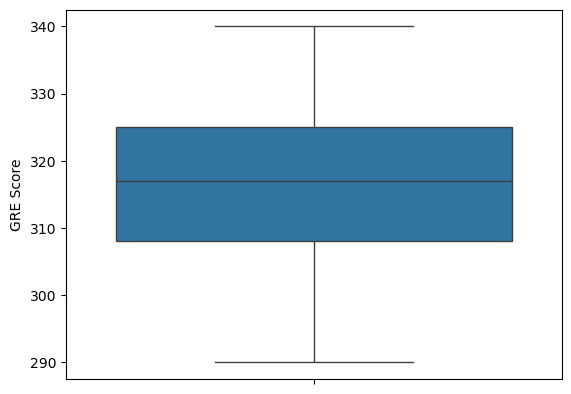

lower_outliers:  Series([], Name: TOEFL Score, dtype: int64)
higher_outliers:  Series([], Name: TOEFL Score, dtype: int64)


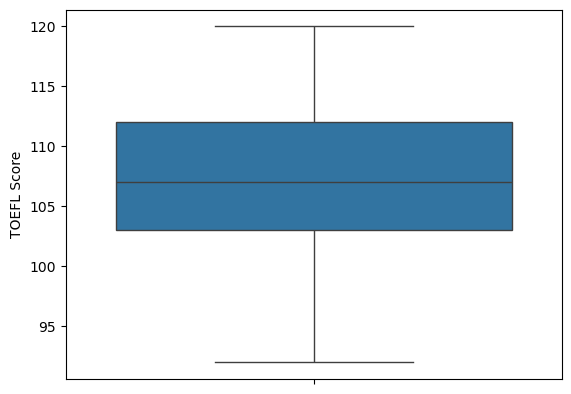

lower_outliers:  Series([], Name: CGPA, dtype: float64)
higher_outliers:  Series([], Name: CGPA, dtype: float64)


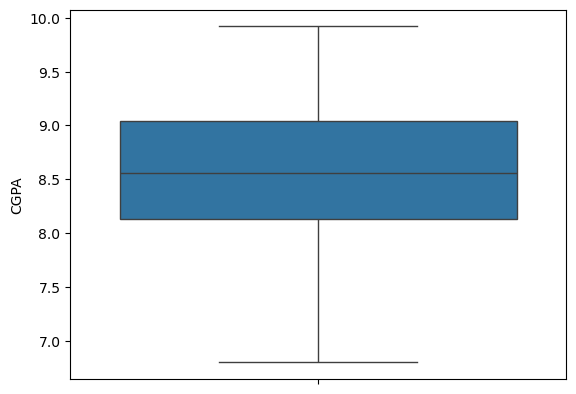

lower_outliers:  92     0.34
376    0.34
Name: Chance of Admit, dtype: float64
higher_outliers:  Series([], Name: Chance of Admit, dtype: float64)


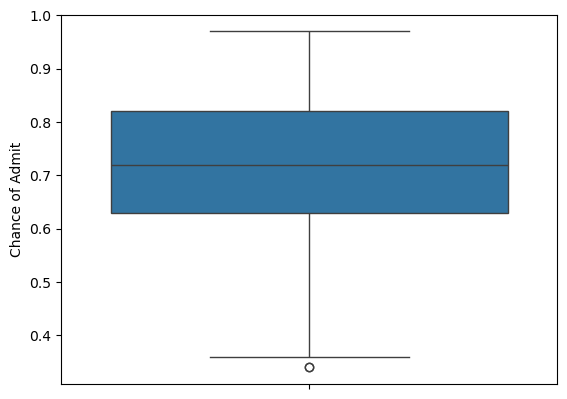

In [43]:
# Exploratory data analysis
# Outlier detection
numeric_cols = ['GRE Score', 'TOEFL Score',
                'CGPA', 'Chance of Admit']
for col in numeric_cols:
    lower_outliers, higher_outliers = outlier_detection(df[col])
    print("lower_outliers: ", lower_outliers)
    print("higher_outliers: ", higher_outliers)
    sns.boxplot(df[col])
    plt.show()

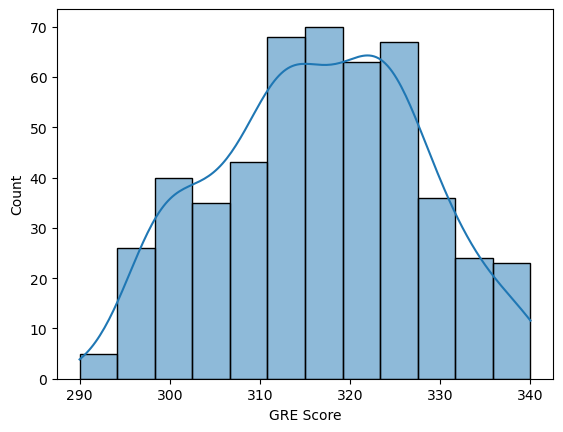

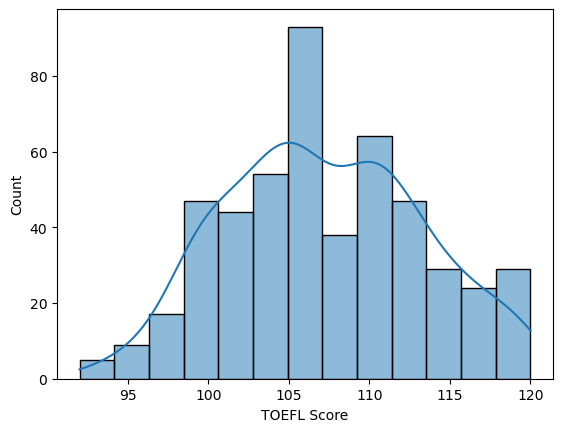

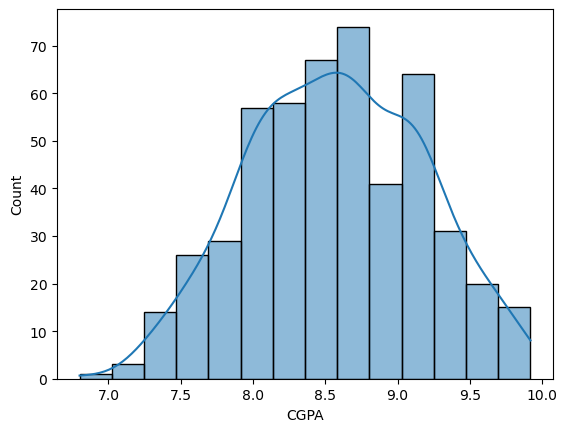

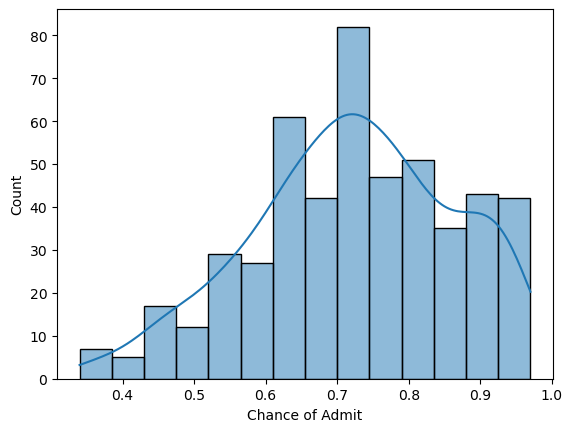

In [47]:
# Univariate analysis
for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

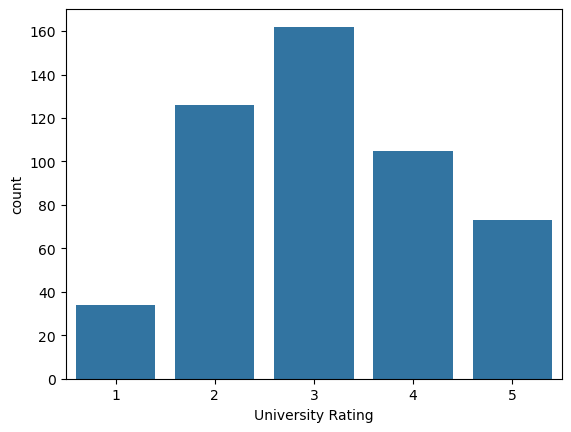

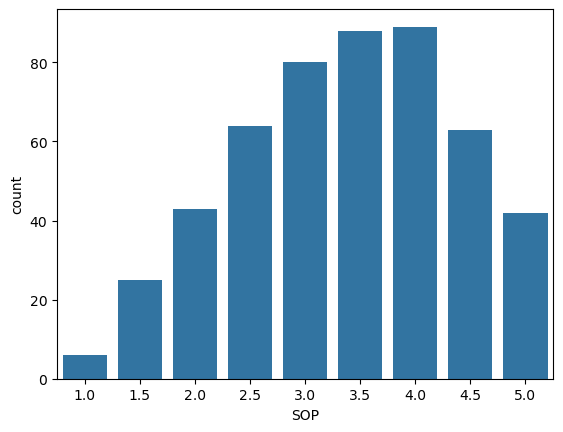

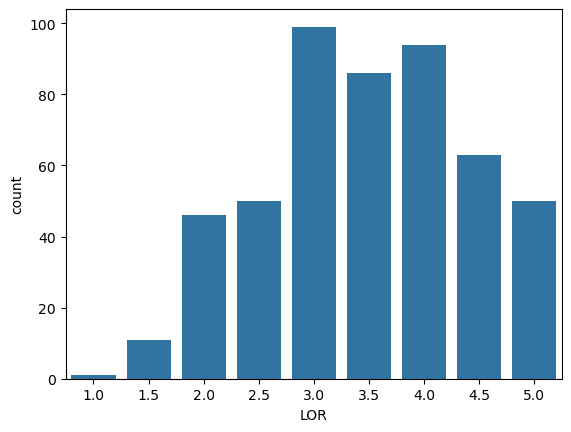

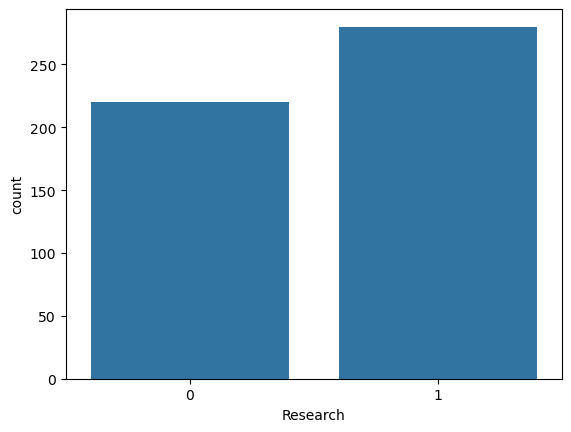

In [53]:
# Categorical variables
categorical_cols = ['University Rating', 'SOP', 'LOR', 'Research']
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.show()

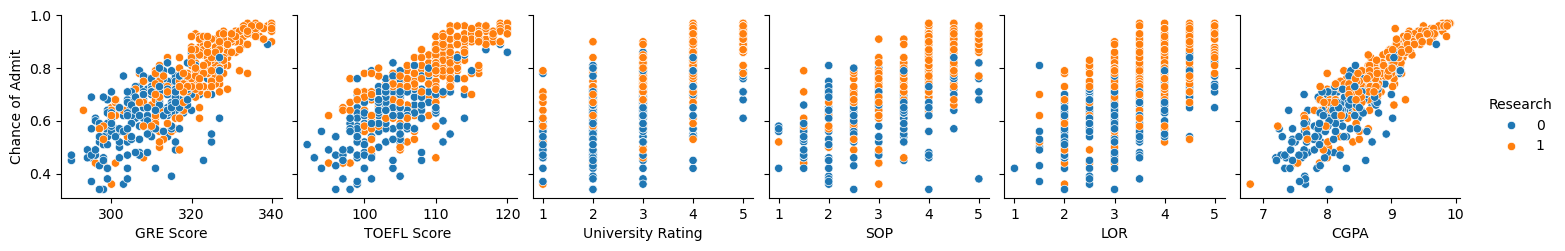

In [55]:
# Bivariate analysis
sns.pairplot(df,
             x_vars=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA'],
             y_vars=['Chance of Admit'],
             hue='Research')
plt.show()

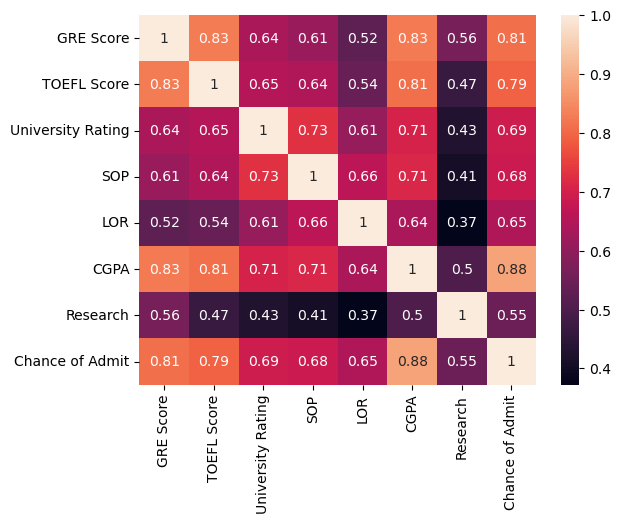

In [59]:
# Multivariate - Heatmap
sns.heatmap(df.corr(), annot=True)
plt.show()

In [67]:
# Using ML to predict chances of admin
# Data preprocessing
# Perform train test split
y = df[['Chance of Admit']]
X = df.drop(columns='Chance of Admit')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 7), (100, 7), (400, 1), (100, 1))

In [69]:
# Standardise the columns
cols_to_standardise = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA']
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X_train[cols_to_standardise])

X_train[cols_to_standardise] = min_max_scaler.transform(X_train[cols_to_standardise])
X_test[cols_to_standardise] = min_max_scaler.transform(X_test[cols_to_standardise])

In [71]:
X_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
249,0.62,0.678571,0.50,0.625,0.714286,0.650641,1
433,0.52,0.678571,0.75,0.750,1.000000,0.557692,0
19,0.26,0.357143,0.50,0.625,0.428571,0.544872,0
322,0.48,0.535714,0.25,0.375,0.714286,0.471154,0
332,0.36,0.500000,0.50,0.625,0.285714,0.451923,1


In [73]:
# Build a linear regression model
X_train_1 = sm.add_constant(X_train)
X_test_1 = sm.add_constant(X_test)

In [75]:
model_1 = sm.OLS(y_train, X_train_1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Sun, 25 May 2025   Prob (F-statistic):          3.41e-142
Time:                        16:03:01   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3556      0.01

In [77]:
y_pred_1 = model_1.predict(X_test_1)

In [79]:
# Model performance
print('MAE: ', mean_absolute_error(y_test, y_pred_1))
print('MSE: ', mean_absolute_error(y_test, y_pred_1))
print('R2: ', r2_score(y_test, y_pred_1))

MAE:  0.04272265427705361
MSE:  0.04272265427705361
R2:  0.8188432567829633


In [81]:
# Test the assumptions of Linear Regression
# Multicollinearity
df_2 = df.drop(columns=['Chance of Admit'])
df_2 = sm.add_constant(df_2)
vif = pd.DataFrame()
vif['Features'] = df_2.columns
vif['vif'] = [variance_inflation_factor(df_2.values, idx) for idx in range(len(df_2.columns))]
vif

,Features,vif
0,const,1511.495830
1,GRE Score,4.464249
2,TOEFL Score,3.904213
3,University Rating,2.621036
4,SOP,2.835210
5,LOR,2.033555
6,CGPA,4.777992
7,Research,1.494008


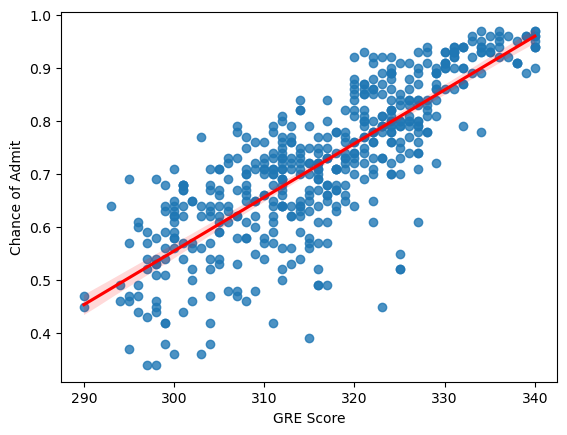

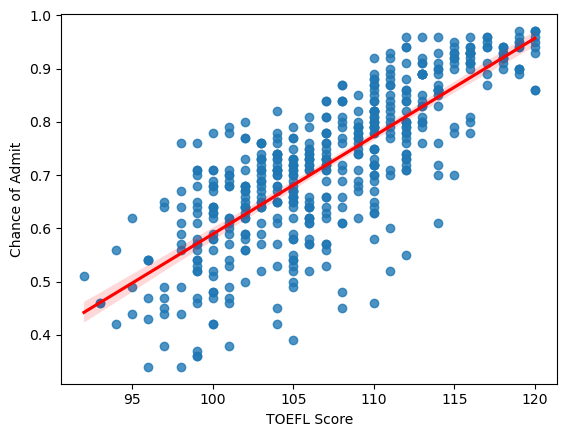

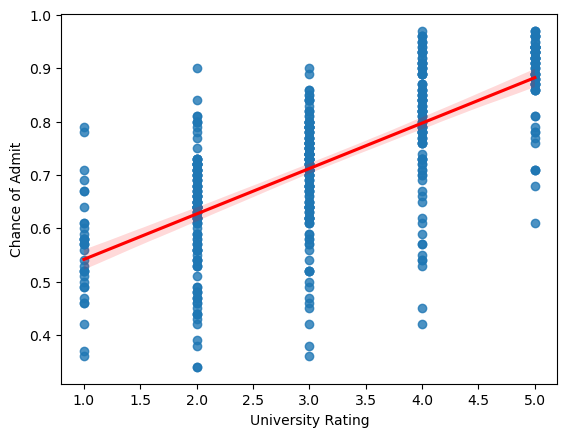

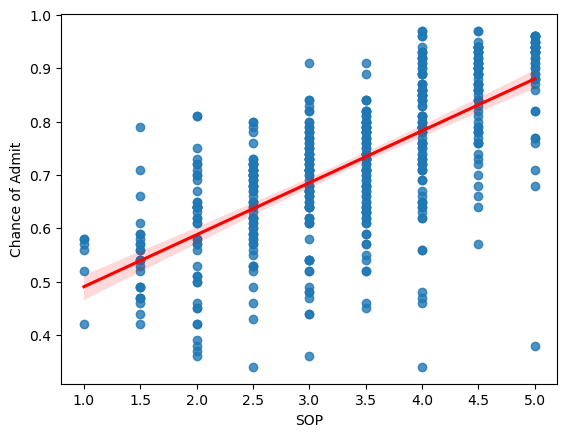

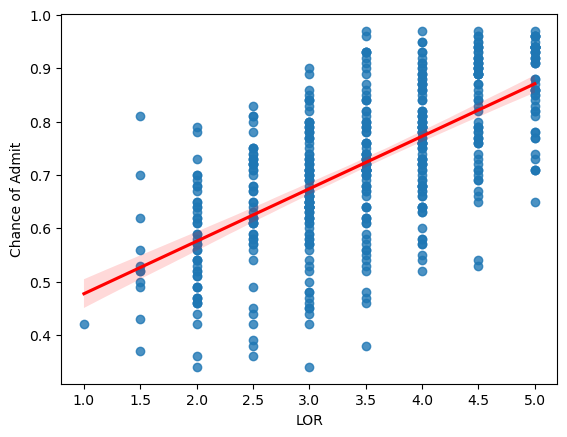

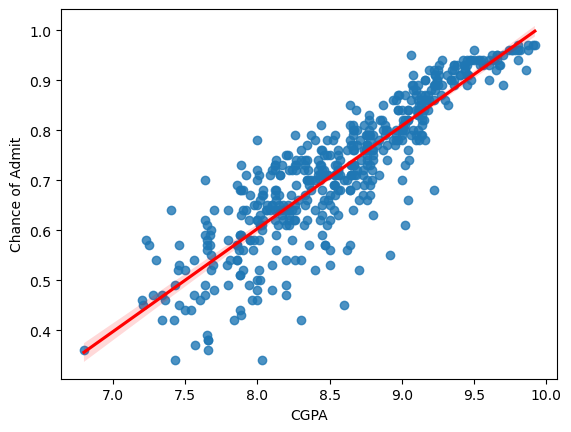

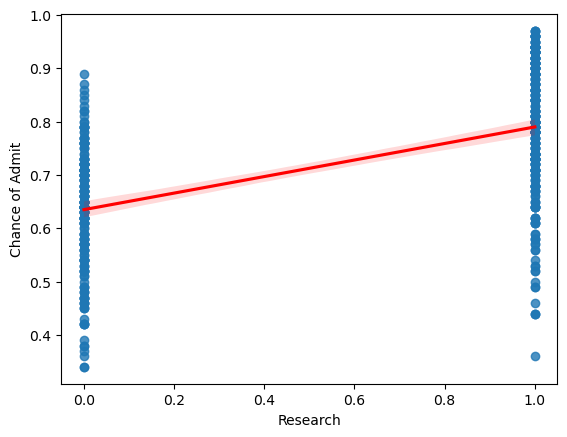

In [87]:
# Test linear relationship
cols = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR',
       'CGPA', 'Research']
for col in cols:
    sns.regplot(data=df, y='Chance of Admit', x=col, line_kws=dict(color='r'))
    plt.show()

In [89]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Model performance
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_absolute_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))

MAE:  0.04272265427705366
MSE:  0.04272265427705366
R2:  0.818843256782963


In [93]:
# Ridge Regression
lr_ridge = Ridge(alpha=0.1)
lr_ridge.fit(X_train, y_train)
y_pred = lr_ridge.predict(X_test)

# Model performance
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_absolute_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))

MAE:  0.04281293477762485
MSE:  0.04281293477762485
R2:  0.8185571087672164


In [95]:
# Lasso Regression
lr_lasso = Lasso(alpha=0.001)
lr_lasso.fit(X_train, y_train)
y_pred = lr_lasso.predict(X_test)

# Model performance
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_absolute_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))

MAE:  0.042159104202376986
MSE:  0.042159104202376986
R2:  0.8202625247911639
